# 06 — Figure editor (styling only, no physics)

**The contract:** the pipeline has already computed everything into
`code/results/*.json`. This notebook only **reads** those JSONs and lets you
restyle figures — colors, fonts, labels, annotation positions — cell by cell.
Nothing here can change a scientific number.

Workflow per figure:
1. edit the `# EDIT ME` knobs in its cell,
2. re-run the cell → see the figure inline,
3. happy? run the `save(...)` line → the PDF lands in `code/results/figures/`
   and **every document picks it up instantly** (they symlink that folder).

⚠ Two rules:
- The **no-overlap guard** runs on save: if your text/legend covers plotted
  data, saving fails with `TEXT-ON-DATA` — move it to empty space.
- A styling change you love should eventually be ported into the figure's
  *generator* (`code/pipeline/figures/…`, map in
  `deliverables/documents/notes/FIGURE_STYLING.md`) so `make figures`
  reproduces it. Until then, re-running `make figures` overwrites your edit.

Global knobs (fonts/colors for *all* figures) live in
`code/src/lunar/plotting/style_overrides.py` — no notebook needed.

In [1]:
# setup: paths, style, data (run once)
import json, numpy as np, matplotlib.pyplot as plt
from lunar._bootstrap import find_repo_root
from lunar.plotting.style import (JGR_HALF, JGR_FULL, C_A15, C_A17, C_HAYNE,
                                  C_CHAR, C_DIM, C_GRID, fmt_axis,
                                  assert_no_overlap)

CODE = find_repo_root()                      # -> <repo>/code
FIGS = CODE / "results" / "figures"
R = json.loads((CODE / "results" / "kd_retrieval_results.json").read_text())

def save(fig, name):
    """Publish to code/results/figures/<name>.pdf (all docs see it).
    Runs the no-overlap guard on every axes first."""
    fig.canvas.draw()
    for ax in fig.axes:
        assert_no_overlap(ax)
    out = FIGS / f"{name}.pdf"
    fig.savefig(out)
    print("published ->", out)

print("data loaded: K_d* =", round(R["A15"]["kd_star"]*1e3, 2), "/",
      round(R["A17"]["kd_star"]*1e3, 2), "mW/m/K")

data loaded: K_d* = 4.6 / 7.08 mW/m/K


## The headline figure (`fig_headline`)
Everything you might want to touch is an `# EDIT ME` line.

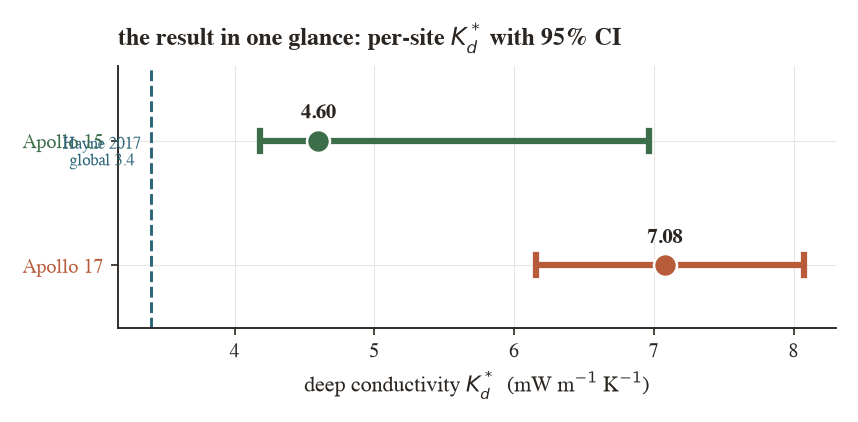

In [2]:
# ---- fig_headline: per-site K_d* with 95% CI --------------------------
star = {s: R[s]["kd_star"]*1e3 for s in ("A15","A17")}
ci   = {s: np.percentile(np.array(R[s]["bootstrap"]["samples"])*1e3, [2.5, 97.5])
        for s in ("A15","A17")}

# EDIT ME ----------------------------------------------------------------
title      = "the result in one glance: per-site $K_d^*$ with 95% CI"
site_label = {"A15": "Apollo 15", "A17": "Apollo 17"}   # y-axis names
site_color = {"A15": C_A15, "A17": C_A17}               # site colors
hayne_x    = 3.4                                        # reference line
hayne_note = "Hayne 2017\nglobal 3.4"                   # its label text
hayne_xy   = (3.05, 0.62)      # label position (x in mW, y in axes 0..1)
marker_sz  = 11                # dot size
value_dy   = 0.18              # vertical offset of the printed value
fig_h      = 2.6               # figure height (inches)
# -------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(JGR_HALF, fig_h), constrained_layout=True)
for y, s in enumerate(("A17", "A15")):
    lo, hi = ci[s]
    ax.plot([lo, hi], [y, y], color=site_color[s], lw=3, solid_capstyle="butt")
    ax.plot([lo, lo], [y-.08, y+.08], color=site_color[s], lw=3)
    ax.plot([hi, hi], [y-.08, y+.08], color=site_color[s], lw=3)
    ax.plot(star[s], y, "o", ms=marker_sz, color=site_color[s],
            mec="white", mew=1.2, zorder=5)
    ax.text(star[s], y + value_dy, f"{star[s]:.2f}", ha="center",
            fontsize=10, fontweight="bold", color=C_CHAR)
ax.axvline(hayne_x, color=C_HAYNE, ls="--", lw=1.4)
ax.text(*hayne_xy, hayne_note, transform=ax.get_xaxis_transform(),
        fontsize=8, color=C_HAYNE, ha="center")
ax.set_yticks([0, 1], [site_label["A17"], site_label["A15"]])
for y, s in zip((0, 1), ("A17", "A15")):
    ax.get_yticklabels()[y].set_color(site_color[s])
fmt_axis(ax, xlabel=r"deep conductivity $K_d^*$  (mW m$^{-1}$ K$^{-1}$)",
         title=title)
ax.set_ylim(-0.5, 1.6)
plt.show()

# happy? publish it (uncomment):
# save(fig, "fig_headline")

## Bootstrap distributions (`fig_bootstrap`, panel a)

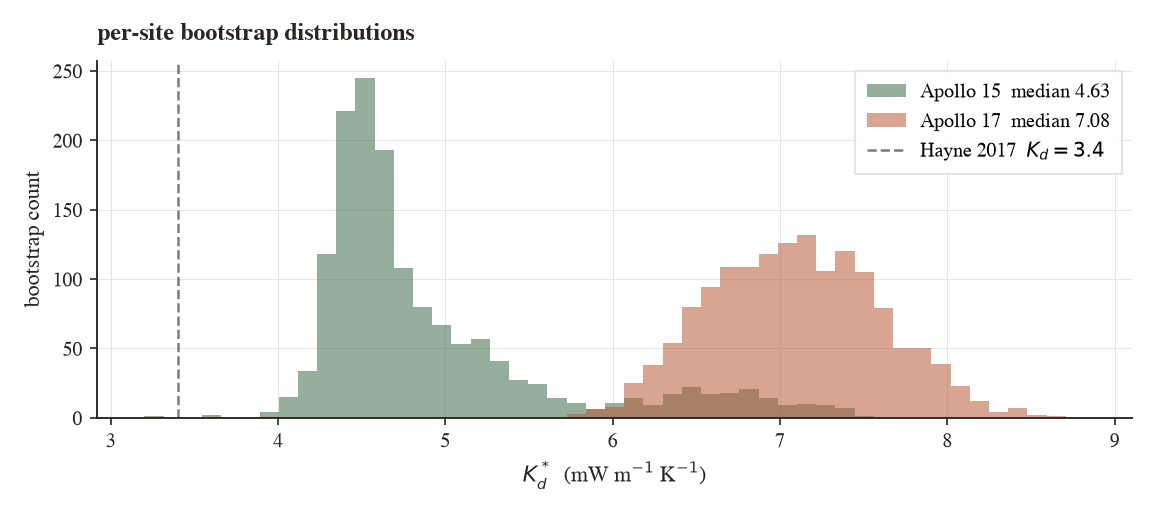

In [3]:
# ---- bootstrap histograms ----------------------------------------------
b15 = np.array(R["A15"]["bootstrap"]["samples"])*1e3
b17 = np.array(R["A17"]["bootstrap"]["samples"])*1e3

# EDIT ME ----------------------------------------------------------------
n_bins     = 50
alpha_fill = 0.55
show_hayne = True
legend_loc = "upper right"     # anywhere empty; guard catches collisions
# -------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(JGR_FULL, 3.2), constrained_layout=True)
bins = np.linspace(min(b15.min(), 3.2), b17.max()+0.2, n_bins)
ax.hist(b15, bins=bins, color=C_A15, alpha=alpha_fill,
        label=f"Apollo 15  median {np.median(b15):.2f}")
ax.hist(b17, bins=bins, color=C_A17, alpha=alpha_fill,
        label=f"Apollo 17  median {np.median(b17):.2f}")
if show_hayne:
    ax.axvline(3.4, color=C_CHAR, ls="--", lw=1.2, alpha=0.6,
               label="Hayne 2017  $K_d=3.4$")
fmt_axis(ax, xlabel=r"$K_d^*$  (mW m$^{-1}$ K$^{-1}$)",
         ylabel="bootstrap count", title="per-site bootstrap distributions")
ax.legend(loc=legend_loc, frameon=True, edgecolor=C_GRID)
plt.show()
# save(fig, "fig_bootstrap_panelA")   # note: the letter's Fig 7 is 2-panel;
# port changes into make_results_figures.fig_bootstrap to affect the paper

## Every other figure
The figure → generator map is in
`deliverables/documents/notes/FIGURE_STYLING.md`. Copy any generator's
plotting block into a cell here, tweak, `save(...)`. To make a change
permanent (survive `make figures`), put the same edit into the generator.